# IGRF Correction

Removing the International Geomagnetic Reference Field (IGRF) from magnetic survey data is a critical part of the processing workflow. Here we demonstrate how to do this in 'airborengeo', utilizing some code from the Python package 'Harmonica'.

In [1]:
# %load_ext autoreload
# %autoreload 2

import cmocean
import matplotlib.pyplot as plt
import pandas as pd
import verde as vd

import airbornegeo

/home/sungw937/airbornegeo/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

This is a subset of the BAS AGAP survey over Antarctica's Gamburtsev Subglacial Mountains. The file is download and subset in the notebook `AGAP_magnetic_survey`.

In [2]:
data_df = pd.read_csv("data/AGAP_magnetic_survey.csv")

# only retain the columns we need
data_df = data_df[
    [
        "Lon",
        "Lat",
        "easting",
        "northing",
        "Height_WGS1984",
        "Date",
        "Time",
        "unixtime",
        "line",
        "MagR",
        "RefField",
    ]
]

data_df = data_df.sort_values(["line", "unixtime"])

# keep only every 20 row to speed up plotting
data_df = data_df[::20]
data_df

,Lon,Lat,easting,northing,Height_WGS1984,Date,Time,unixtime,line,MagR,RefField
0,75.635600,-84.104393,6.210722e+05,159052.962392,4109.4,2008-12-17,0 days 07:53:42,1.229500e+09,1,55143.17,55133.06
20,75.645801,-84.094070,6.221899e+05,159221.159183,4134.0,2008-12-17,0 days 07:54:03,1.229500e+09,1,55127.58,55132.63
40,75.653676,-84.083888,6.232863e+05,159410.463641,4135.4,2008-12-17,0 days 07:54:23,1.229500e+09,1,55115.74,55132.61
60,75.662205,-84.073454,6.244112e+05,159599.143002,4133.4,2008-12-17,0 days 07:54:43,1.229500e+09,1,55108.25,55132.70
80,75.671227,-84.062810,6.255597e+05,159787.772567,4151.4,2008-12-17,0 days 07:55:03,1.229501e+09,1,55103.03,55132.38
...,...,...,...,...,...,...,...,...,...,...,...
1060300,84.295793,-80.008286,1.082884e+06,108166.469739,4191.2,2009-01-06,0 days 13:38:38.440000,1.231249e+09,206,55992.37,56050.06
1060320,84.216115,-80.009295,1.082622e+06,109661.140637,4191.1,2009-01-06,0 days 13:38:58.440000,1.231249e+09,206,55969.54,56038.73
1060340,84.136530,-80.010339,1.082355e+06,111153.145716,4190.2,2009-01-06,0 days 13:39:18.440000,1.231249e+09,206,55942.08,56027.43
1060360,84.056840,-80.011228,1.082103e+06,112648.360155,4191.6,2009-01-06,0 days 13:39:38.440000,1.231249e+09,206,55907.00,56016.03


## IGRF for a single data
For short durations surveys (hours or days) it is reasonable to calculate the IGRF model at a single time, since secular variations are typically small for these timescales. Below we will use date of the first row to compute the IGRF field for the entire survey.

In [3]:
# make a datetime column
data_df["datetime"] = data_df.Date + " " + data_df.Time.str.split("days ").str.get(1)
data_df.head()

,Lon,Lat,easting,northing,Height_WGS1984,Date,Time,unixtime,line,MagR,RefField,datetime
0,75.635600,-84.104393,621072.177354,159052.962392,4109.4,2008-12-17,0 days 07:53:42,1.229500e+09,1,55143.17,55133.06,2008-12-17 07:53:42
20,75.645801,-84.094070,622189.859392,159221.159183,4134.0,2008-12-17,0 days 07:54:03,1.229500e+09,1,55127.58,55132.63,2008-12-17 07:54:03
40,75.653676,-84.083888,623286.279285,159410.463641,4135.4,2008-12-17,0 days 07:54:23,1.229500e+09,1,55115.74,55132.61,2008-12-17 07:54:23
60,75.662205,-84.073454,624411.189918,159599.143002,4133.4,2008-12-17,0 days 07:54:43,1.229500e+09,1,55108.25,55132.70,2008-12-17 07:54:43
80,75.671227,-84.062810,625559.719601,159787.772567,4151.4,2008-12-17,0 days 07:55:03,1.229501e+09,1,55103.03,55132.38,2008-12-17 07:55:03


In [4]:
intensity, inc, dec = airbornegeo.igrf(
    data_df,
    datetime_column="datetime",
    latitude_column="Lat",
    longitude_column="Lon",
    height_column="Height_WGS1984",
)
data_df["IGRF_intensity_1datetime"] = intensity
data_df["IGRF_inc"] = inc
data_df["IGRF_dec"] = dec
data_df.head()

,Lon,Lat,easting,northing,Height_WGS1984,Date,Time,unixtime,line,MagR,RefField,datetime,IGRF_intensity_1datetime,IGRF_inc,IGRF_dec
0,75.635600,-84.104393,621072.177354,159052.962392,4109.4,2008-12-17,0 days 07:53:42,1.229500e+09,1,55143.17,55133.06,2008-12-17 07:53:42,55085.052201,-72.438106,-95.445248
20,75.645801,-84.094070,622189.859392,159221.159183,4134.0,2008-12-17,0 days 07:54:03,1.229500e+09,1,55127.58,55132.63,2008-12-17 07:54:03,55084.689233,-72.438409,-95.441030
40,75.653676,-84.083888,623286.279285,159410.463641,4135.4,2008-12-17,0 days 07:54:23,1.229500e+09,1,55115.74,55132.61,2008-12-17 07:54:23,55084.750247,-72.438458,-95.434496
60,75.662205,-84.073454,624411.189918,159599.143002,4133.4,2008-12-17,0 days 07:54:43,1.229500e+09,1,55108.25,55132.70,2008-12-17 07:54:43,55084.943474,-72.438532,-95.428265
80,75.671227,-84.062810,625559.719601,159787.772567,4151.4,2008-12-17,0 days 07:55:03,1.229501e+09,1,55103.03,55132.38,2008-12-17 07:55:03,55084.642334,-72.438708,-95.422346


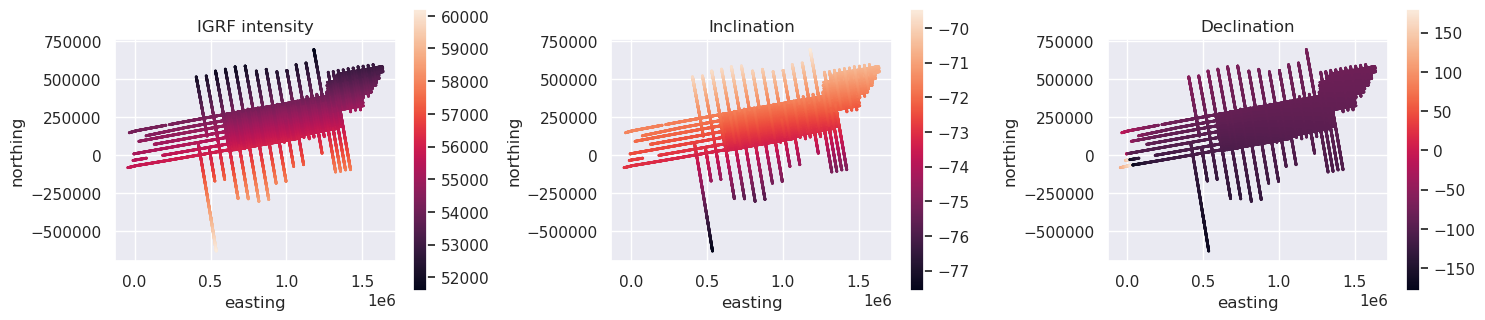

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="IGRF_intensity_1datetime",
    s=1,
    ax=axs[0],
    colorbar=False,
    title="IGRF intensity",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="IGRF_inc",
    s=1,
    ax=axs[1],
    colorbar=False,
    title="Inclination",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="IGRF_dec",
    s=1,
    ax=axs[2],
    colorbar=False,
    title="Declination",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

## IGRF for each flight
If our survey spans more than a few days, or high accuracy is required, we can compute the IGRF field at multiple timesteps, for example, for each day, flight, or line.

For this survey, we don't have flight ID's, so we will split the survey on gaps in time larger than six hours, and calculate the IGRF individually for each of these segments. 

Number of segments: 13


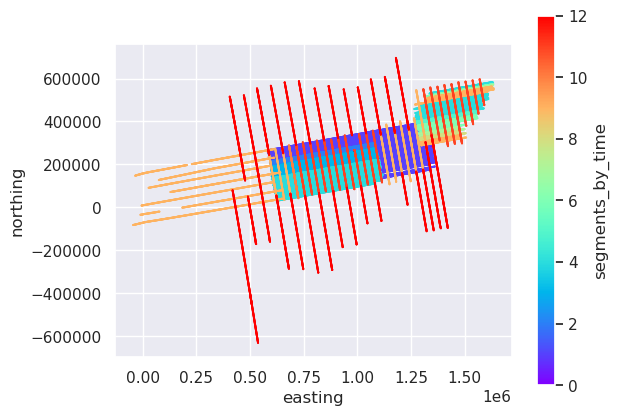

In [6]:
data_df["segments_by_time"] = airbornegeo.split_into_segments(
    data_df,
    column_name="unixtime",
    threshold=60 * 60 * 60 * 6,  # 6 hrs
)
print(f"Number of segments: {len(data_df.segments_by_time.unique())}")

ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="segments_by_time",
    s=0.2,
    cmap="rainbow",
)
ax.set_aspect("equal")

In [7]:
intensity, inc, dec = airbornegeo.igrf(
    data_df,
    datetime_column="datetime",
    latitude_column="Lat",
    longitude_column="Lon",
    height_column="Height_WGS1984",
    groupby_column="segments_by_time",
)
data_df["IGRF_intensity"] = intensity
data_df["IGRF_inc"] = inc
data_df["IGRF_dec"] = dec
data_df.head()

Segments: 100%|██████████| 13/13 [00:00<00:00, 78.84it/s]


,Lon,Lat,easting,northing,Height_WGS1984,Date,Time,unixtime,line,MagR,RefField,datetime,IGRF_intensity_1datetime,IGRF_inc,IGRF_dec,segments_by_time,IGRF_intensity
0,75.635600,-84.104393,621072.177354,159052.962392,4109.4,2008-12-17,0 days 07:53:42,1.229500e+09,1,55143.17,55133.06,2008-12-17 07:53:42,55085.052201,-72.438106,-95.445248,0,55085.052201
20,75.645801,-84.094070,622189.859392,159221.159183,4134.0,2008-12-17,0 days 07:54:03,1.229500e+09,1,55127.58,55132.63,2008-12-17 07:54:03,55084.689233,-72.438409,-95.441030,0,55084.689233
40,75.653676,-84.083888,623286.279285,159410.463641,4135.4,2008-12-17,0 days 07:54:23,1.229500e+09,1,55115.74,55132.61,2008-12-17 07:54:23,55084.750247,-72.438458,-95.434496,0,55084.750247
60,75.662205,-84.073454,624411.189918,159599.143002,4133.4,2008-12-17,0 days 07:54:43,1.229500e+09,1,55108.25,55132.70,2008-12-17 07:54:43,55084.943474,-72.438532,-95.428265,0,55084.943474
80,75.671227,-84.062810,625559.719601,159787.772567,4151.4,2008-12-17,0 days 07:55:03,1.229501e+09,1,55103.03,55132.38,2008-12-17 07:55:03,55084.642334,-72.438708,-95.422346,0,55084.642334


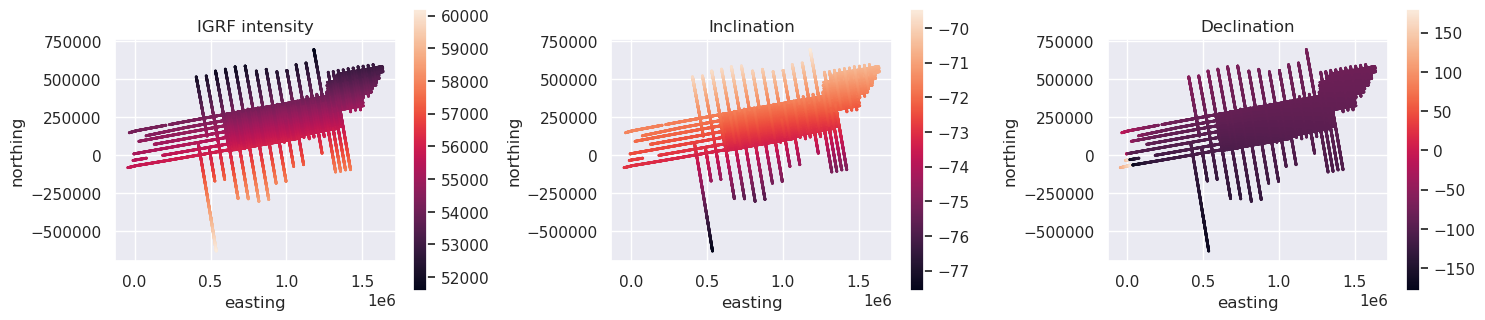

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="IGRF_intensity",
    s=1,
    ax=axs[0],
    colorbar=False,
    title="IGRF intensity",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="IGRF_inc",
    s=1,
    ax=axs[1],
    colorbar=False,
    title="Inclination",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="IGRF_dec",
    s=1,
    ax=axs[2],
    colorbar=False,
    title="Declination",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

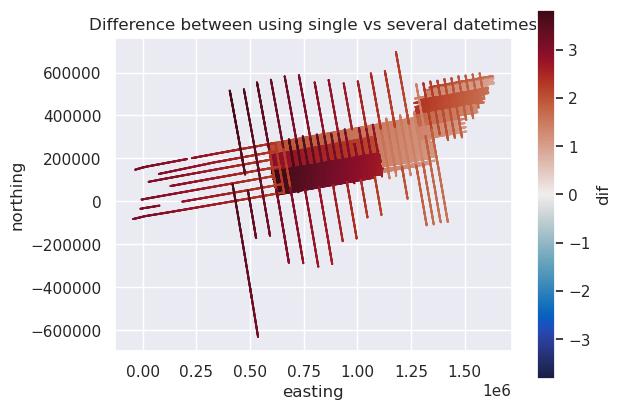

In [9]:
# compare the intenties using only 1 datetime and multiple
data_df["dif"] = data_df.IGRF_intensity_1datetime - data_df.IGRF_intensity

maxabs = vd.maxabs(data_df.dif, percentile=100)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="dif",
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    s=0.2,
    title="Difference between using single vs several datetimes",
)
ax.set_aspect("equal")

## Calculate total field anomalies
We can now subtract the IGRF intensities from the observations to get a total field anomaly.

In [10]:
data_df["total_field_anomaly"] = data_df.MagR - data_df.IGRF_intensity
data_df.head()

,Lon,Lat,easting,northing,Height_WGS1984,Date,Time,unixtime,line,MagR,RefField,datetime,IGRF_intensity_1datetime,IGRF_inc,IGRF_dec,segments_by_time,IGRF_intensity,dif,total_field_anomaly
0,75.635600,-84.104393,621072.177354,159052.962392,4109.4,2008-12-17,0 days 07:53:42,1.229500e+09,1,55143.17,55133.06,2008-12-17 07:53:42,55085.052201,-72.438106,-95.445248,0,55085.052201,0.0,58.117799
20,75.645801,-84.094070,622189.859392,159221.159183,4134.0,2008-12-17,0 days 07:54:03,1.229500e+09,1,55127.58,55132.63,2008-12-17 07:54:03,55084.689233,-72.438409,-95.441030,0,55084.689233,0.0,42.890767
40,75.653676,-84.083888,623286.279285,159410.463641,4135.4,2008-12-17,0 days 07:54:23,1.229500e+09,1,55115.74,55132.61,2008-12-17 07:54:23,55084.750247,-72.438458,-95.434496,0,55084.750247,0.0,30.989753
60,75.662205,-84.073454,624411.189918,159599.143002,4133.4,2008-12-17,0 days 07:54:43,1.229500e+09,1,55108.25,55132.70,2008-12-17 07:54:43,55084.943474,-72.438532,-95.428265,0,55084.943474,0.0,23.306526
80,75.671227,-84.062810,625559.719601,159787.772567,4151.4,2008-12-17,0 days 07:55:03,1.229501e+09,1,55103.03,55132.38,2008-12-17 07:55:03,55084.642334,-72.438708,-95.422346,0,55084.642334,0.0,18.387666


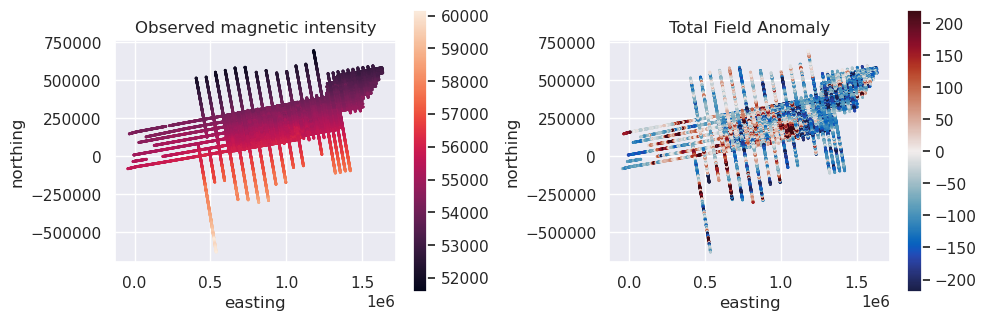

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="MagR",
    s=1,
    ax=axs[0],
    colorbar=False,
    title="Observed magnetic intensity",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

maxabs = vd.maxabs(data_df.total_field_anomaly, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="total_field_anomaly",
    s=1,
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    ax=axs[1],
    colorbar=False,
    title="Total Field Anomaly",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

### Compare with the IGRF values in the published dataset

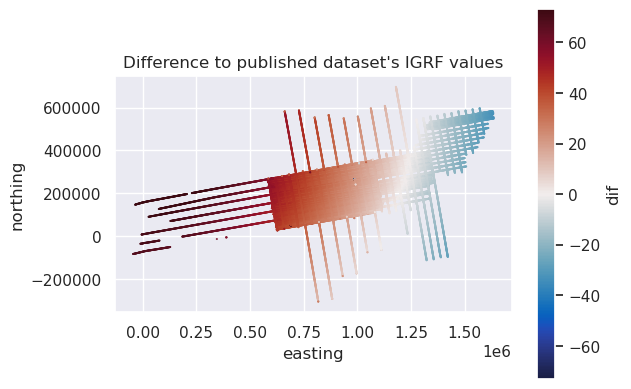

In [12]:
# compare to the IGRF values used in the published dataset
data_df["dif"] = data_df.RefField - data_df.IGRF_intensity

maxabs = vd.maxabs(data_df.dif, percentile=99)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="dif",
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    s=0.2,
    title="Difference to published dataset's IGRF values",
)
ax.set_aspect("equal")